# Q5 — Are some platforms systematically optimistic/pessimistic?

**How is the baseline set?** A naive bias = *rating − mean of all platforms* is biased
toward zero because the platform is part of its own baseline. We therefore report several
established measures and compare them:

- **Raw mean rating** per platform (uncontrolled).
- **Leave-one-out (LOO) deviation** — each rating minus the consensus of the *other*
  platforms only. This is the cleanest signed-bias measure (no self-inclusion).
- **Pairwise signed differences** (A − B over venues on both) — model-free and symmetric.

(A two-way fixed-effects model *rating ~ restaurant + platform* would give an equivalent
platform effect; with at most three platforms the LOO/pairwise measures capture the same
signal without the extra machinery.)

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


In [2]:
rows = run(queries.q5_platform_rows())
cols = {"google": "google_rating_5", "tripadvisor": "tripadvisor_rating_5", "thefork": "thefork_rating_5"}

bias = []
for p, c in cols.items():
    others = [oc for op, oc in cols.items() if op != p]
    present = rows[rows[c].notna()]
    consensus_loo = present[others].mean(axis=1)            # mean of the OTHER platforms
    bias.append({
        "platform": p,
        "rated_venues": int(present[c].notna().sum()),
        "mean_rating": round(present[c].mean(), 3),
        "loo_deviation": round((present[c] - consensus_loo).mean(), 3),
        "dev_from_consensus": round((present[c] - present["rating_avg_5"]).mean(), 3),
    })
q5_bias = publish(pd.DataFrame(bias), "q5_platform_bias",
                  "Q5 — Platform bias: raw mean, leave-one-out deviation, deviation from consensus.")
q5_bias

,platform,rated_venues,mean_rating,loo_deviation,dev_from_consensus
0,google,4070,4.296,0.308,0.157
1,tripadvisor,3913,3.939,-0.362,-0.191
2,thefork,886,4.437,0.180,0.122


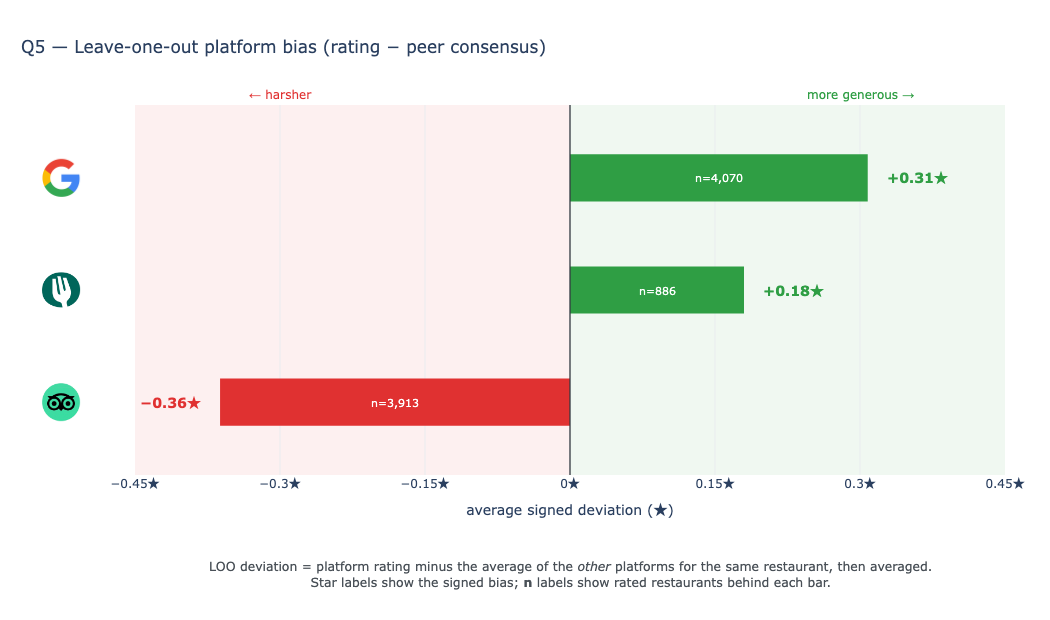

In [3]:
# LOO deviation per platform: a signed bias against the *other* platforms' consensus.
# Bars show the average star deviation; in-bar n labels show the number of restaurants
# contributing to that platform mean. Platform logos replace text labels.
POS, NEG = "#2F9E44", "#E03131"
MUTED = "#495057"


def _signed_star(v):  # signed value with a real minus sign and ★ suffix
    return f"{'+' if v >= 0 else '−'}{abs(v):.2f}★"


d = q5_bias.sort_values("loo_deviation").reset_index(drop=True)  # harsher → generous
ys = list(range(len(d)))
_xmin, _xmax = -0.45, 0.45

fig = go.Figure()
fig.add_vrect(x0=_xmin, x1=0, fillcolor="rgba(224,49,49,0.075)", line_width=0, layer="below")
fig.add_vrect(x0=0, x1=_xmax, fillcolor="rgba(47,158,68,0.075)", line_width=0, layer="below")
fig.add_bar(
    x=d["loo_deviation"], y=ys, orientation="h", width=0.42, cliponaxis=False,
    marker_color=[POS if v >= 0 else NEG for v in d["loo_deviation"]],
    marker_line_width=0, customdata=d[["platform", "rated_venues"]],
    hovertemplate="%{customdata[0]}<br>LOO deviation %{x:.2f}★<br>n=%{customdata[1]:,}<extra></extra>",
)
fig.add_vline(x=0, line_color="#343A40", line_width=1.3)

for i, row in d.iterrows():
    v = row["loo_deviation"]
    fig.add_annotation(
        x=v + (0.018 if v >= 0 else -0.018), y=i, showarrow=False,
        text=f"<b>{_signed_star(v)}</b>",
        xanchor="left" if v >= 0 else "right", yanchor="middle",
        font=dict(size=14, color=POS if v >= 0 else NEG),
    )
    fig.add_annotation(
        x=v * 0.5, y=i, showarrow=False, text=f"n={int(row['rated_venues']):,}",
        xanchor="center", yanchor="middle", font=dict(size=11, color="white"),
    )
    fig.add_layout_image(dict(
        source=logo_uri(row["platform"]), xref="paper", yref="y",
        x=-0.085, y=i, sizex=0.058, sizey=0.34,
        xanchor="center", yanchor="middle", sizing="contain", layer="above",
    ))

fig.add_annotation(x=-0.30, y=1.055, xref="x", yref="paper", showarrow=False,
                   text="← harsher", font=dict(size=12, color=NEG))
fig.add_annotation(x=0.30, y=1.055, xref="x", yref="paper", showarrow=False,
                   text="more generous →", font=dict(size=12, color=POS))
fig.add_annotation(
    xref="paper", yref="paper", x=0.5, y=-0.22, xanchor="center", yanchor="top",
    align="center", showarrow=False, font=dict(size=12.5, color="#495057"),
    text=("LOO deviation = platform rating minus the average of the <i>other</i> platforms "
          "for the same restaurant, then averaged.<br>"
          "Star labels show the signed bias; <b>n</b> labels show rated restaurants behind each bar."),
)
fig.update_layout(
    template="plotly_white", showlegend=False, bargap=0.5,
    title=dict(text="Q5 — Leave-one-out platform bias (rating − peer consensus)", x=0.02, xanchor="left"),
    margin=dict(l=135, r=45, t=105, b=145),
)
fig.update_xaxes(
    range=[_xmin, _xmax], dtick=0.15, ticksuffix="★", zeroline=False,
    gridcolor="#E9ECEF", title_text="average signed deviation (★)",
)
fig.update_yaxes(tickvals=ys, showticklabels=False, range=[-0.65, len(d) - 0.35], showgrid=False)
fig.show()


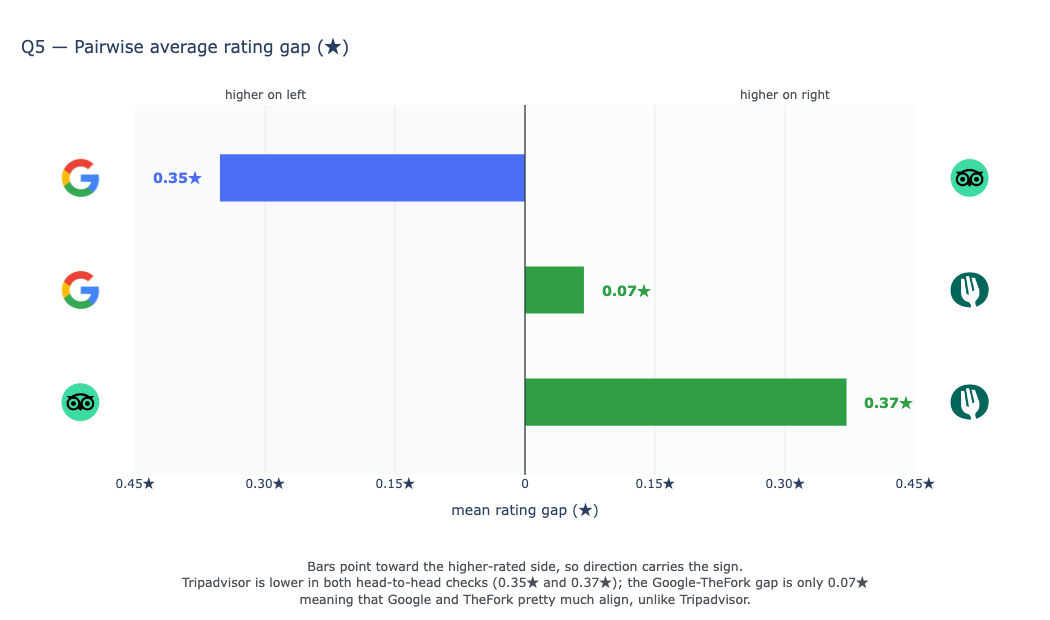

,pair,venues,mean_signed_diff
0,google - thefork,886,-0.068
1,google - tripadvisor,3913,0.352
2,tripadvisor - thefork,729,-0.371


In [8]:
q5_pair = publish(run(queries.q5_pairwise_differences()), "q5_pairwise_differences",
                  "Q5 — Mean signed rating difference per ordered platform pair (A − B).")

# Pairwise rating gap over restaurants present on both platforms. The sign is visual:
# bars point toward the side with the higher average rating.

p = q5_pair.copy()
p[["a", "b"]] = p["pair"].str.split(" - ", expand=True)
p = p.sort_values("mean_signed_diff").reset_index(drop=True)
p["gap"] = p["mean_signed_diff"].abs()
p["display_gap"] = np.where(p["mean_signed_diff"] >= 0, -p["gap"], p["gap"])
p["higher"] = np.where(p["mean_signed_diff"] >= 0, p["a"], p["b"])
ys = list(range(len(p)))
_xmin, _xmax = -0.45, 0.45
_pair_vals = dict(zip(q5_pair["pair"], q5_pair["mean_signed_diff"]))

fig = go.Figure()
fig.add_vrect(x0=_xmin, x1=0, fillcolor="rgba(248,249,250,0.90)", line_width=0, layer="below")
fig.add_vrect(x0=0, x1=_xmax, fillcolor="rgba(248,249,250,0.55)", line_width=0, layer="below")
fig.add_bar(
    x=p["display_gap"], y=ys, orientation="h", width=0.42, cliponaxis=False,
    marker_color=[PLATFORM_COLORS[h] for h in p["higher"]], marker_line_width=0,
    customdata=p[["pair", "venues", "gap", "higher"]],
    hovertemplate="%{customdata[0]}<br>%{customdata[3]} higher by %{customdata[2]:.2f}★<br>n=%{customdata[1]:,}<extra></extra>",
)
fig.add_vline(x=0, line_color="#343A40", line_width=1.3)

for i, row in p.iterrows():
    v = row["display_gap"]
    c = PLATFORM_COLORS[row["higher"]]
    fig.add_annotation(
        x=v + (0.018 if v >= 0 else -0.018), y=i, showarrow=False,
        text=f"<b>{row['gap']:.2f}★</b>",
        xanchor="left" if v >= 0 else "right", yanchor="middle",
        font=dict(size=14, color=c),
    )
    fig.add_layout_image(dict(
        source=logo_uri(row.a), xref="paper", yref="y", x=-0.070, y=i,
        sizex=0.052, sizey=0.34, xanchor="center", yanchor="middle",
        sizing="contain", layer="above",
    ))
    fig.add_layout_image(dict(
        source=logo_uri(row.b), xref="paper", yref="y", x=1.070, y=i,
        sizex=0.052, sizey=0.34, xanchor="center", yanchor="middle",
        sizing="contain", layer="above",
    ))

fig.add_annotation(x=-0.30, y=1.055, xref="x", yref="paper", showarrow=False,
                   text="higher on left", font=dict(size=12, color="#495057"))
fig.add_annotation(x=0.30, y=1.055, xref="x", yref="paper", showarrow=False,
                   text="higher on right", font=dict(size=12, color="#495057"))
fig.add_annotation(
    xref="paper", yref="paper", x=0.5, y=-0.22, xanchor="center", yanchor="top",
    align="center", showarrow=False, font=dict(size=12.5, color="#495057"),
    text=("Bars point toward the higher-rated side, so direction carries the sign.<br>"
          f"Tripadvisor is lower in both head-to-head checks "
          f"({abs(_pair_vals['google - tripadvisor']):.2f}★ and "
          f"{abs(_pair_vals['tripadvisor - thefork']):.2f}★); "
          f"the Google-TheFork gap is only {abs(_pair_vals['google - thefork']):.2f}★<br>"
          f"meaning that Google and TheFork pretty much align, unlike Tripadvisor."),
)
fig.update_layout(
    template="plotly_white", showlegend=False, bargap=0.5,
    title=dict(text="Q5 — Pairwise average rating gap (★)", x=0.02, xanchor="left"),
    margin=dict(l=135, r=135, t=105, b=145),
)
fig.update_xaxes(
    range=[_xmin, _xmax], tickvals=[-0.45, -0.30, -0.15, 0, 0.15, 0.30, 0.45],
    ticktext=["0.45★", "0.30★", "0.15★", "0", "0.15★", "0.30★", "0.45★"],
    zeroline=False, gridcolor="#E9ECEF", title_text="mean rating gap (★)",
)
fig.update_yaxes(tickvals=ys, showticklabels=False, range=[-0.65, len(p) - 0.35], showgrid=False)
fig.show()
q5_pair


**Answer (Q5):** The stable signal is directional: **Tripadvisor is
systematically harsher** than the other platforms. Google and TheFork both sit on the
generous side, but their exact ordering depends on the baseline: TheFork is slightly higher
than Google on their direct overlap, while Google has the larger leave-one-out deviation.
The robust conclusion is therefore not a full three-platform ranking, but a clear
Tripadvisor-vs-peers bias.
